# 🔗 LangGraph: Multi-Step Prompt Chaining Workflow

### 📌 Overview
This notebook implements the canonical **Prompt Chaining** workflow pattern using OpenRouter's free **`stealth/union-alpha`** model.

A long-form generation task is broken into two sequential, dependent stages:
1. **Stage 1 (`create_outline`):** Analyzes the title and plans a structured outline.
2. **Stage 2 (`create_blog`):** Ingests the title *and* the newly generated outline from state to write a complete, in-depth blog post.

---

### 🗺️ Graph Topology

```text
┌─────────┐       ┌──────────────────┐       ┌───────────────┐       ┌───────┐
│  START  │ ────► │  create_outline  │ ────► │  create_blog  │ ────► │  END  │
└─────────┘       └──────────────────┘       └───────────────┘       └───────┘
```

*Execution Order:* `START` ➔ `create_outline` (LLM 1) ➔ `create_blog` (LLM 2) ➔ `END`

In [1]:
import os
from typing import NotRequired, TypedDict
from dotenv import load_dotenv
from IPython.display import Image, display
from langchain_openai import ChatOpenAI
from langgraph.graph import END, START, StateGraph

# Load variables from .env
load_dotenv()

# Verify OpenRouter key
if not os.getenv("OPENROUTER_API_KEY"):
    raise ValueError(
        "OPENROUTER_API_KEY is missing. Please add it to your .env file: "
        "OPENROUTER_API_KEY=sk-or-v1-..."
    )

### 2. Initialize LLM via OpenRouter
We use `ChatOpenAI` configured with OpenRouter's base URL and the free `stealth/union-alpha` model.

In [ ]:
# OpenRouter configuration with stealth/union-alpha
model = ChatOpenAI(
    model="stealth/union-alpha",
    api_key=os.getenv("OPENROUTER_API_KEY"),
    base_url="https://openrouter.ai/api/v1",
    temperature=0.7,
)

### 3. Define Graph State Schema
The state contract defines:
* `title`: Required initial user input.
* `outline`: Generated by Node 1 (`NotRequired` initially).
* `content`: Generated by Node 2 (`NotRequired` initially).

In [3]:
class BlogState(TypedDict):
    title: str
    outline: NotRequired[str]
    content: NotRequired[str]

### 4. Define Graph Nodes (Functional Pattern)
Each node performs one dedicated step and returns **only its state delta**:
* `create_outline`: Produces section headings and bullet points.
* `create_blog`: Consumes the generated outline from `state["outline"]` and drafts the complete article.

In [4]:
def create_outline(state: BlogState) -> dict:
    """Node 1: Generates a structured outline from the title."""
    title = state["title"]

    messages = [
        (
            "system",
            "You are an expert content strategist. Create clear, comprehensive, "
            "and well-structured blog outlines with section headings and bullet points.",
        ),
        ("human", f"Generate a detailed outline for a blog post titled: '{title}'"),
    ]

    response = model.invoke(messages)
    # Return only the state delta
    return {"outline": str(response.content)}


def create_blog(state: BlogState) -> dict:
    """Node 2: Consumes the outline from Node 1 and writes the complete article."""
    title = state["title"]
    outline = state["outline"]

    messages = [
        (
            "system",
            "You are an engaging professional tech writer. "
            "Write an in-depth article that expands thoroughly on each section of the provided outline.",
        ),
        (
            "human",
            f"Write a comprehensive blog post for '{title}' adhering strictly to this outline:\n\n{outline}",
        ),
    ]

    response = model.invoke(messages)
    # Return only the state delta
    return {"content": str(response.content)}

### 5. Build and Compile the Workflow
We wire the execution pipeline: `START` ➔ `create_outline` ➔ `create_blog` ➔ `END`.

In [5]:
# 1. Initialize StateGraph
builder = StateGraph(BlogState)

# 2. Add nodes
builder.add_node("create_outline", create_outline)
builder.add_node("create_blog", create_blog)

# 3. Add edges (Linear Chain)
builder.add_edge(START, "create_outline")
builder.add_edge("create_outline", "create_blog")
builder.add_edge("create_blog", END)

# 4. Compile graph into a runnable
workflow = builder.compile()

### 6. Execute the Workflow
We invoke the compiled graph with an initial topic and observe the sequential output.

In [6]:
initial_input = {"title": "The Rise of Agentic AI in Autonomous Software Engineering"}

# --- Batch Invocation ---
print("--- Running Workflow (.invoke) ---\n")
final_state = workflow.invoke(initial_input)

print("=" * 60)
print("1. GENERATED OUTLINE:")
print("=" * 60)
print(final_state["outline"])

print("\n" + "=" * 60)
print("2. FINAL BLOG CONTENT:")
print("=" * 60)
print(final_state["content"])

--- Running Workflow (.invoke) ---

1. GENERATED OUTLINE:
# Blog Outline: The Rise of Agentic AI in Autonomous Software Engineering

## Blog Metadata
- **Target audience:** Engineering leaders, CTOs, VPs of Engineering, senior developers, DevOps/platform teams, AI product leaders
- **Search intent:** Informational + strategic; readers want to understand what agentic AI is, why it matters, and how to adopt it safely
- **Primary keyword:** agentic AI in software engineering
- **Secondary keywords:** autonomous software engineering, AI coding agents, multi-agent systems, AI in SDLC, autonomous DevOps, AI software development
- **Meta description:** Explore how agentic AI is moving software engineering from AI-assisted coding to autonomous execution—and what it means for teams, tooling, risks, and the future of development.
- **Estimated reading time:** 10–14 minutes

---

## 1. Introduction: From AI Copilots to Autonomous Engineers
- **Hook:** For years, AI has autocompleted code. Now it 

### 7. Visualize Graph Topology
Displays the topology graph with an automatic offline ASCII fallback.

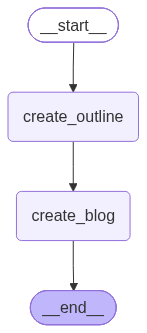

In [7]:
try:
    display(Image(workflow.get_graph().draw_mermaid_png()))
except Exception:
    print("Mermaid image renderer unavailable. Displaying ASCII graph instead:\n")
    print(workflow.get_graph().draw_ascii())